<a href="https://colab.research.google.com/github/Koginitiv-Analytics/supply-chain-logistics-intelligence/blob/main/inventory_abc_reorder_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.12k/9.12k [00:00<00:00, 14.3MB/s]

Extracting files...
Dataset Shape: (100, 24)
  Product type   SKU      Price  Availability  Number of products sold  \
0     haircare  SKU0  69.808006            55                      802   
1     skincare  SKU1  14.843523            95                      736   
2     haircare  SKU2  11.319683            34                        8   
3     skincare  SKU3  61.163343            68                       83   
4     skincare  SKU4   4.805496            26                      871   

   Revenue generated Customer demographics  Stock levels  Lead times  \
0        8661.996792            Non-binary            58           7   
1        7460.900065                Female            53          30   
2        9577.749626               Unknown             1          10   
3        7766.836426            Non-binary            23          13   
4        2686.505152            Non-binary             5           3   

   Order quantities  ...  Location Lead time  Production volumes  \
0        


/tmp/ipykernel_1273/1602105855.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Safe(False)', 'Reorder Urgently(True)'])


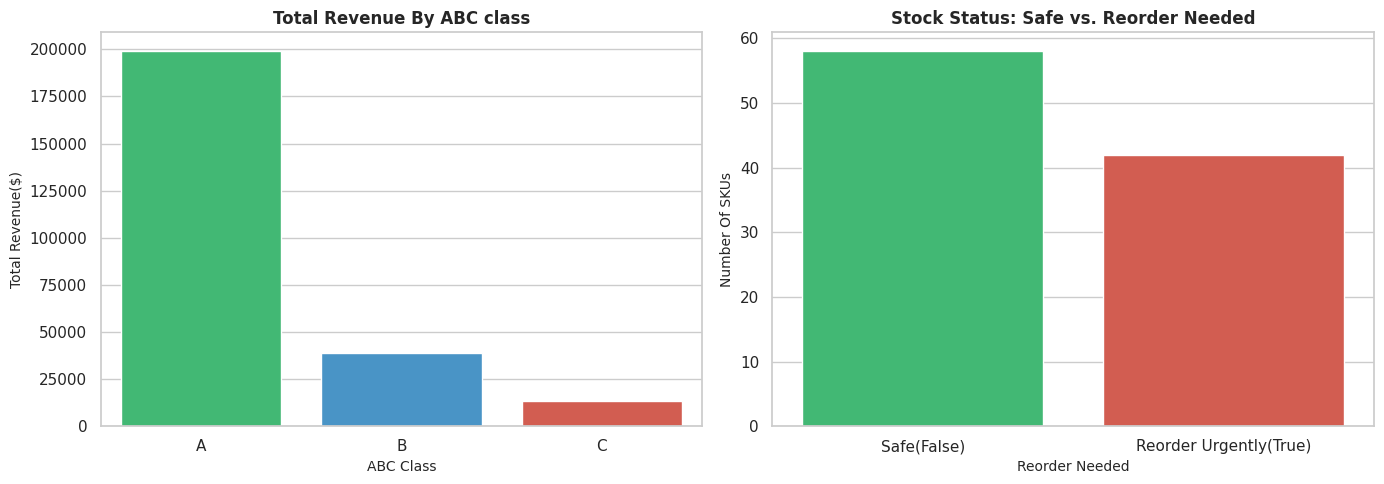

In [1]:
import pandas as pd
import numpy as np
import kagglehub
import os

path = kagglehub.dataset_download("harshsingh2209/supply-chain-analysis")

csv_path = os.path.join(path, "supply_chain_data.csv")

df = pd.read_csv(csv_path)

print("Dataset Shape:", df.shape)
print(df.head())


df['Avg_Daily_Sales'] = df['Order quantities'] / 30


df['Safety_Stock'] = np.ceil(df['Avg_Daily_Sales'] * 3)


df['Reorder_Point'] = np.ceil((df['Avg_Daily_Sales'] * df['Lead times']) + df['Safety_Stock'])


df['Reorder_Alert'] = df['Stock levels'] < df['Reorder_Point']


reorder_needed = df[df['Reorder_Alert'] == True][['SKU', 'Stock levels', 'Reorder_Point', 'Safety_Stock', 'Lead times', 'Avg_Daily_Sales', 'Reorder_Alert']]

print(f"Total SKUs needing immediate reorder: {len(reorder_needed)}")
reorder_needed.head(10)

df['Total_Revenue'] = df['Price'] * df['Order quantities']


df = df.sort_values(by='Total_Revenue', ascending=False).reset_index(drop=True)

df['Cum_Revenue'] = df['Total_Revenue'].cumsum()
df['Cum_Percen'] = (df['Cum_Revenue'] / df['Total_Revenue'].sum()) * 100

def assign_abc(perc):
    if perc <= 80:
        return 'A'
    elif perc <= 95:
        return 'B'
    else:
        return 'C'

df['ABC_class'] = df['Cum_Percen'].apply(assign_abc)

print(df['ABC_class'].value_counts())

df[['SKU', 'Price', 'Order quantities', 'Total_Revenue', 'Cum_Percen', 'ABC_class']].head(10)

critical_reorders = df[df['Reorder_Alert'] == True][['SKU', 'ABC_class', 'Reorder_Point', 'Total_Revenue']]

print("---URGENT REORDER CLASS---")
print(critical_reorders['ABC_class'].value_counts())


critical_reorders[critical_reorders['ABC_class'] == 'A'].head(10)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=df,
    x='ABC_class',
    y='Total_Revenue',
    hue='ABC_class',
    estimator=sum,
    errorbar=None,
    palette=['#2ecc71', '#3498db', '#e74c3c'],
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Total Revenue By ABC class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('ABC Class', fontsize=10)
axes[0].set_ylabel('Total Revenue($)', fontsize=10)

sns.countplot(
    data=df,
    x='Reorder_Alert',
    hue='Reorder_Alert',
    palette=['#2ecc71', '#e74c3c'],
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Stock Status: Safe vs. Reorder Needed', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Reorder Needed', fontsize=10)
axes[1].set_ylabel('Number Of SKUs', fontsize=10)
axes[1].set_xticklabels(['Safe(False)', 'Reorder Urgently(True)'])

plt.tight_layout()
plt.show()